# Poynting Flux in FDTDX: Measuring Energy Flow Through an Interface

This notebook is a small, self-contained tutorial that builds a 3D FDTD simulation with **[FDTDX](https://fdtdx.readthedocs.io/en/latest/)** and uses a **Poynting flux detector** to measure how electromagnetic energy flows through a chosen interface (a plane) inside the simulation volume, over time.

**What we build:**

1. A simulation volume filled with vacuum, surrounded by **PML absorbing boundaries on all six sides** (so waves leaving the volume are absorbed instead of reflecting back in).
2. A **`GaussianPlaneSource`** — a plane wave with a transverse Gaussian intensity profile — injecting light into the volume.
3. A **`PoyntingFluxDetector`** placed on a plane through the middle of the volume, which integrates the instantaneous Poynting vector over that plane at every time step.
4. A plot of the power — and the cumulative energy — flowing through that plane as a function of time.

**Background — what is the Poynting flux?**

The Poynting vector

$$\vec{S}(t) = \vec{E}(t) \times \vec{H}(t)$$

points in the direction electromagnetic energy is flowing and has units of W/m². Integrating $\vec S$ over a surface $A$ gives the instantaneous **power** crossing that surface,

$$P(t) = \iint_A \vec{S}(t) \cdot d\vec{A},$$

and integrating that power over time gives the **energy** that has flowed through the surface,

$$U(t) = \int_0^t P(t')\, dt'.$$

A `PoyntingFluxDetector` computes exactly this surface integral at every recorded time step — that scalar time series is what we plot below, together with its running time-integral $U(t)$.


# 1. Imports

FDTDX is built on [JAX](https://docs.jax.dev/), so a simulation is really just a JAX computation: build a set of `SimulationObject`s, resolve their placement, then `jax.jit`-compile and run the FDTD time loop.

In [2]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import fdtdx

%matplotlib inline

## 2. Simulation configuration

`SimulationConfig` sets the overall FDTD parameters: total simulated time, spatial resolution (grid spacing), numeric dtype, and the Courant safety factor for the time step.

We use a vacuum wavelength of 1.55 µm (telecom C-band) and a resolution of 100 nm, so the wave is resolved with about 15 grid points per wavelength.

> If you don't have a GPU available, pass `backend="cpu"` to `SimulationConfig` — everything else in this notebook stays the same.

In [7]:
# Vacuum wavelength of the source
wavelength = 1.55e-6  # meters

# JAX random key (FDTDX always needs one, even for a fully deterministic run)
key = jax.random.PRNGKey(seed=42)

# We collect every simulation object in this list as we build the scene
object_list = []

config = fdtdx.SimulationConfig(
    time=80e-15,          # total simulated time: 80 fs
    grid=fdtdx.UniformGrid(spacing=100e-9),    # grid spacing: 100 nm
    dtype=jnp.float32,
    courant_factor=0.99,
)

print(f"Time step duration : {config.time_step_duration * 1e15:.4f} fs")
print(f"Total time steps   : {config.time_steps_total}")

Time step duration : 0.1907 fs
Total time steps   : 420


## 3. Simulation volume

The `SimulationVolume` defines the overall extent of the simulation and the background material that fills any space not occupied by another object — here, vacuum ($\varepsilon_r = \mu_r = 1$). We use a 10 µm cube.

In [10]:
volume = fdtdx.SimulationVolume(
    partial_real_shape=(10e-6, 10e-6, 10e-6),
    material=fdtdx.Material(  # vacuum background
        permittivity=1.0,
        permeability=1.0,
    ),
)
object_list.append(volume)

# Constraints describe how objects are positioned/sized relative to each other.
# We build this list up as we add every object below.
constraints = []

## 4. Boundaries: PML on all six sides

FDTDX provides a shortcut, `BoundaryConfig.from_uniform_bound`, that creates the same boundary condition on every side of the volume. We use `boundary_type="pml"` (Perfectly Matched Layer) everywhere, with a thickness of 10 grid cells (= 1 µm). PML absorbs outgoing waves almost perfectly, so radiation that leaves the simulation volume doesn't reflect back in and corrupt the flux measurement.

In [13]:
bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(thickness=10, boundary_type="pml")
bound_dict, bound_constraints = fdtdx.boundary_objects_from_config(bound_cfg, volume)

object_list.extend(bound_dict.values())
constraints.extend(bound_constraints)

## 5. A simple Gaussian source

`GaussianPlaneSource` injects a plane wave with a Gaussian transverse intensity profile (`radius` and `std` control its size and how sharply it falls off at the edges — keep enough energy away from the edges to avoid artifacts). We place it near the top of the volume and set `direction="-"` so it propagates downward, toward $-z$.

By default this source uses a `SingleFrequencyProfile` in time: a continuous wave at a single frequency, with a smooth ramp-up over its first few periods (instead of switching on abruptly, which would inject a burst of unwanted frequencies). Keep that in mind when we look at the flux plot later — we should expect it to ramp up too, not switch on instantly.

In [16]:
source = fdtdx.GaussianPlaneSource(
    name="GaussianSource",
    partial_grid_shape=(None, None, 1),
    partial_real_shape=(8e-6, 8e-6, None),
    fixed_E_polarization_vector=(1, 0, 0),
    wave_character=fdtdx.WaveCharacter(wavelength=wavelength),
    radius=3e-6,
    std=1 / 3,
    direction="-",  # propagate toward -z
)
object_list.append(source)

constraints.append(
    source.place_relative_to(
        volume,
        axes=(0, 1, 2),
        own_positions=(0, 0, 1),
        other_positions=(0, 0, 1),
        margins=(0, 0, -1.5e-6),  # push the source 1.5 um below the top PML
    )
)

## 6. Poynting flux detector — measuring the interface

`PoyntingFluxDetector` is a plane detector (one grid cell thick along its `propagation_axis`) that, at every recorded time step, computes the Poynting vector $\vec S = \vec E \times \vec H$ over its plane and — since `reduce_volume=True` — sums it (weighted by the physical area of each grid cell) into a **single number: the instantaneous power (in Watts) crossing that plane**.

We place it as a plane spanning the full $x$–$y$ cross-section, centered at $z=0$ (the mid-height of the volume, a few microns below the source) — this is our "interface". Setting `direction="-"` matches the source's propagation direction, so the recorded power is positive while energy is flowing the same way the source is emitting it.

In [19]:
pf_detector = fdtdx.PoyntingFluxDetector(
    name="InterfaceFlux",
    partial_grid_shape=(None, None, 1),
    direction="-",       # measure flux flowing in the -z direction (same as the source)
    reduce_volume=True,  # sum over the whole plane -> one scalar (Watts) per time step
)
object_list.append(pf_detector)

constraints.extend(
    [
        pf_detector.place_relative_to(
            volume,
            axes=(0, 1, 2),
            own_positions=(0, 0, 0),
            other_positions=(0, 0, 0),
        ),  # centered in the volume -> the detector plane sits at z = 0
        pf_detector.same_size(volume, axes=(0, 1)),  # span the full x-y cross-section
    ]
)

## 7. Resolve the scene and take a look

`place_objects` turns all the relative constraints above into concrete grid coordinates. `plot_setup` then renders a cross-section of the scene, so we can sanity-check the geometry (PML shading around the edges, the orange source plane, the green detector plane) before spending any time running the simulation.

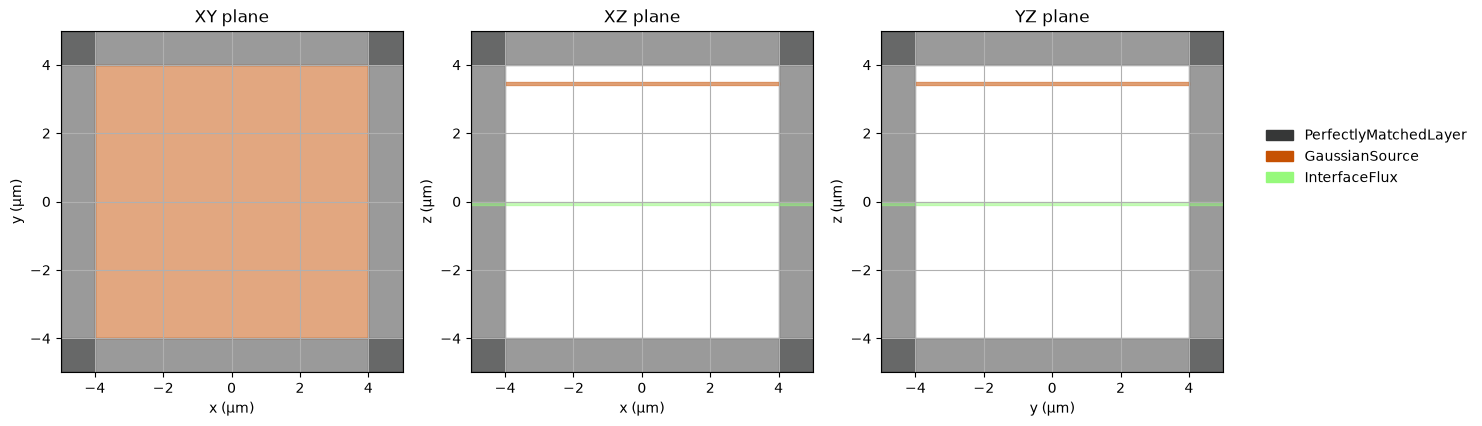

In [22]:
key, subkey = jax.random.split(key)
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list=object_list,
    config=config,
    constraints=constraints,
    key=subkey,
)

fig = fdtdx.plot_setup(config=config, objects=objects)
plt.show()

## 8. Run the FDTD simulation

Running an FDTDX simulation is a two-step process:

1. `apply_params` applies any (here: no) design parameters and precomputes values used throughout the simulation.
2. `run_fdtd` performs the actual FDTD time-stepping loop, updating the detector state at every step along the way.

We wrap both in a function and `jax.jit`-compile it, which is what makes FDTDX fast.

In [25]:
def sim_fn(
    params: fdtdx.ParameterContainer,
    arrays: fdtdx.ArrayContainer,
    key: jax.Array,
):
    # Apply parameters to objects and arrays
    arrays, new_objects, _ = fdtdx.apply_params(arrays, objects, params, key)

    # Run the FDTD simulation (forward in time)
    final_state = fdtdx.run_fdtd(
        arrays=arrays,
        objects=new_objects,
        config=config,
        key=key,
    )
    _, arrays = final_state
    return arrays


start_time = time.time()
jitted_sim = jax.jit(sim_fn).lower(params, arrays, key).compile()
print(f"Compilation time: {time.time() - start_time:.2f} s")

Compilation time: 0.38 s


In [27]:
start_time = time.time()
new_arrays = jitted_sim(params, arrays, subkey)
print(f"Simulation runtime: {time.time() - start_time:.2f} s")

FDTD (checkpointed):   0%|                            | 0/420 [00:00<?, ?step/s]

Simulation runtime: 2.31 s


## 9. Plot the Poynting flux over time

Every detector's recorded data lives in `new_arrays.detector_states[<name>]`, a dictionary of arrays. For a `PoyntingFluxDetector` the key is `"poynting_flux"`, and with `reduce_volume=True` its shape is `(num_recorded_steps, 1)` — one power value per recorded time step. We flatten it to a 1D array and build a matching time axis from `config.time_step_duration`.

What to expect: the wave takes a few femtoseconds to travel from the source down to the detector plane, so the flux stays at zero at first. Once the wavefront arrives, power ramps up over the source's few-period startup, and then — because this is a **continuous-wave** source — settles into a steady oscillation at *twice* the optical frequency. That's expected physics, not noise: for a sinusoidal field the instantaneous power is $P(t) \propto \cos^2(\omega t)$, which oscillates between zero and a peak value rather than sitting at a constant level.

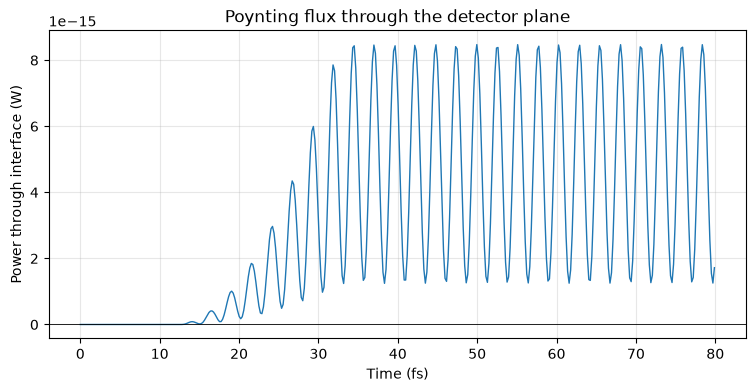

In [30]:
poynting_flux = np.asarray(new_arrays.detector_states["InterfaceFlux"]["poynting_flux"]).reshape(-1)

dt = float(config.time_step_duration)
t = np.arange(poynting_flux.shape[0]) * dt  # seconds, one entry per recorded step

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t * 1e15, poynting_flux, color="tab:blue", lw=1.0)
ax.axhline(0.0, color="black", lw=0.6)
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Power through interface (W)")
ax.set_title("Poynting flux through the detector plane")
ax.grid(alpha=0.3)
plt.show()

## 10. Cumulative energy through the interface

Power is energy *per unit time*. Running a cumulative (trapezoidal) integral of $P(t)$ over time turns it into the actual **energy, in Joules, that has flowed through the interface** up to time $t$ — a direct answer to "how much energy crossed this plane?".

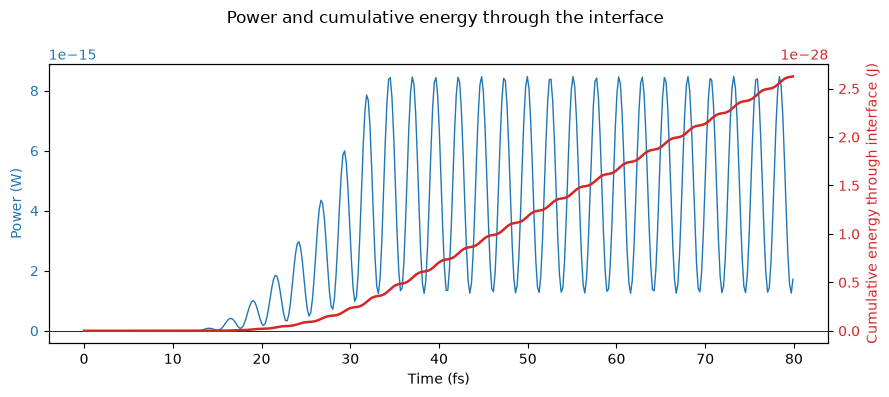

Total energy that flowed through the interface: 2.625e-28 J


In [34]:
# Cumulative trapezoidal integral of P(t) -> energy in Joules
energy = np.concatenate(
    [[0.0], np.cumsum(0.5 * (poynting_flux[:-1] + poynting_flux[1:]) * dt)]
)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(t * 1e15, poynting_flux, color="tab:blue", lw=1.0, label="Power $P(t)$")
ax1.set_xlabel("Time (fs)")
ax1.set_ylabel("Power (W)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.axhline(0.0, color="black", lw=0.6)

ax2 = ax1.twinx()
ax2.plot(t * 1e15, energy, color="tab:red", lw=1.8, label="Cumulative energy $U(t)$")
ax2.set_ylabel("Cumulative energy through interface (J)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

fig.suptitle("Power and cumulative energy through the interface")
fig.tight_layout()
plt.show()

print(f"Total energy that flowed through the interface: {energy[-1]:.3e} J")